In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

In [39]:
# load dataset
df = pd.read_csv(r"D:\Project\Machine Learning\Churn Modelling\data\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [41]:
# removing null values
df.dropna(inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9998 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9998 non-null   int64  
 1   CustomerId       9998 non-null   int64  
 2   Surname          9998 non-null   object 
 3   CreditScore      9998 non-null   int64  
 4   Geography        9998 non-null   object 
 5   Gender           9998 non-null   object 
 6   Age              9998 non-null   float64
 7   Tenure           9998 non-null   int64  
 8   Balance          9998 non-null   float64
 9   NumOfProducts    9998 non-null   int64  
 10  HasCrCard        9998 non-null   float64
 11  IsActiveMember   9998 non-null   float64
 12  EstimatedSalary  9998 non-null   float64
 13  Exited           9998 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [43]:
# analysis columns
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [44]:
# remove unnecessary columns
df.drop(columns = ["RowNumber", "CustomerId", "Surname"], inplace=True)

In [45]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

C:\Users\ROHIT RANE\AppData\Local\Temp\ipykernel_28836\1177488693.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CreditScore"])


<Axes: xlabel='CreditScore', ylabel='Density'>

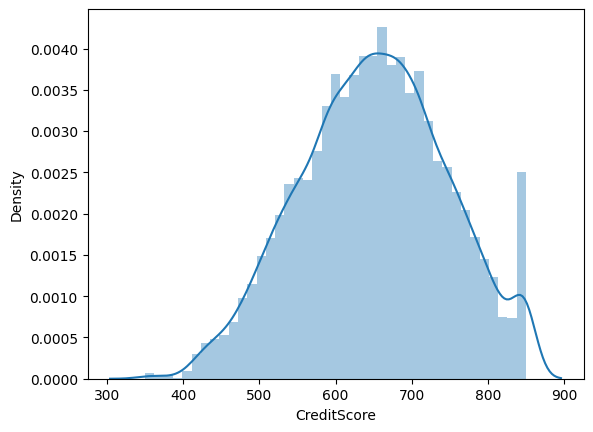

In [46]:
sns.distplot(df["CreditScore"])

In [47]:
df['Geography'].value_counts()

Geography
France     5012
Germany    2510
Spain      2476
Name: count, dtype: int64

In [48]:
df['Gender'].value_counts()

Gender
Male      5455
Female    4543
Name: count, dtype: int64

In [49]:
df['AgeCategory'] = pd.cut(df['Age'], bins = [17, 25, 40, 60, 100], labels = ['Adult', 'Mid Age', 'Senior', 'Old Age'])

In [50]:
df['AgeCategory'].value_counts()

AgeCategory
Mid Age    5808
Senior     3115
Adult       611
Old Age     464
Name: count, dtype: int64

In [51]:
df.drop(columns = ["Age"], inplace=True)

In [52]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeCategory'],
      dtype='object')

C:\Users\ROHIT RANE\AppData\Local\Temp\ipykernel_28836\1059757808.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Tenure'])


<Axes: xlabel='Tenure', ylabel='Density'>

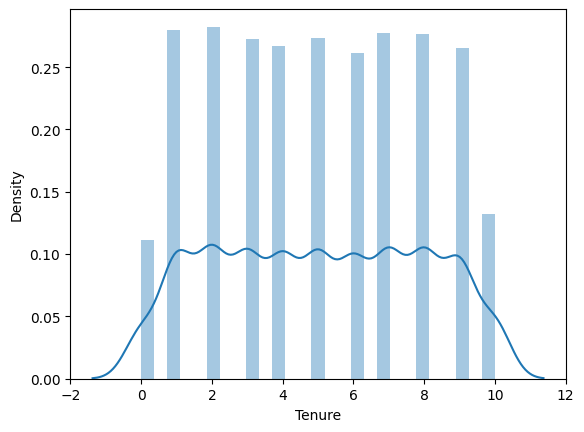

In [53]:
sns.distplot(df['Tenure'])

C:\Users\ROHIT RANE\AppData\Local\Temp\ipykernel_28836\4103663901.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Balance'].value_counts())


<Axes: xlabel='count', ylabel='Density'>

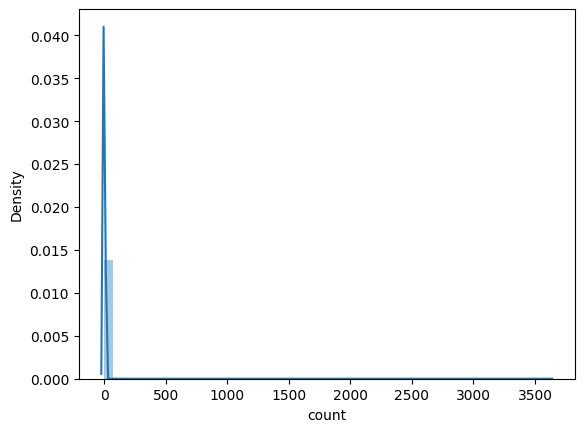

In [54]:
sns.distplot(df['Balance'].value_counts())

C:\Users\ROHIT RANE\AppData\Local\Temp\ipykernel_28836\2751247072.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['NumOfProducts'])


<Axes: xlabel='NumOfProducts', ylabel='Density'>

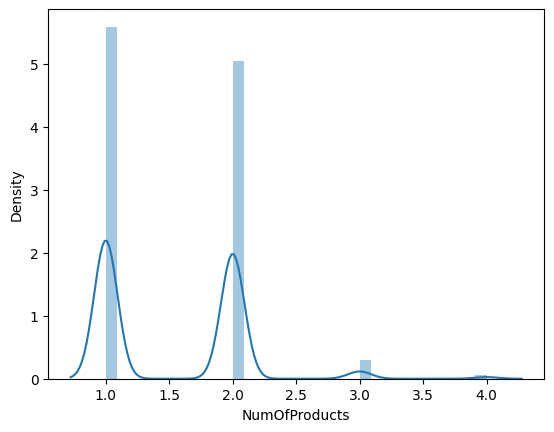

In [55]:
sns.distplot(df['NumOfProducts'])

C:\Users\ROHIT RANE\AppData\Local\Temp\ipykernel_28836\1518140711.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['HasCrCard'])


<Axes: xlabel='HasCrCard', ylabel='Density'>

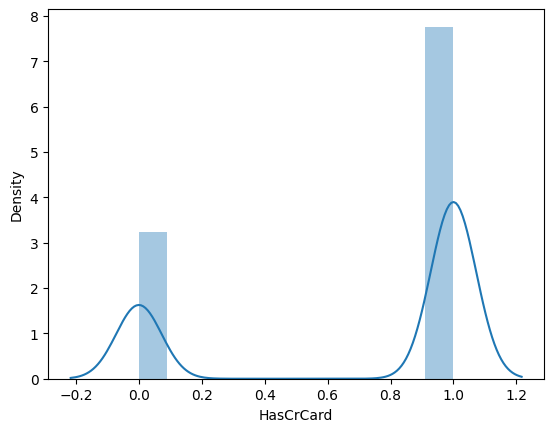

In [56]:
sns.distplot(df['HasCrCard'])

C:\Users\ROHIT RANE\AppData\Local\Temp\ipykernel_28836\1371270078.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['IsActiveMember'])


<Axes: xlabel='IsActiveMember', ylabel='Density'>

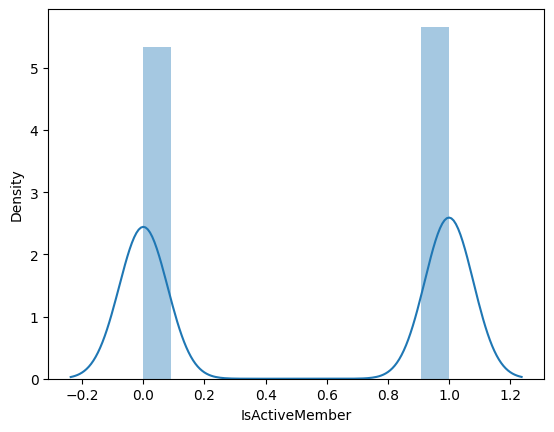

In [57]:
sns.distplot(df['IsActiveMember'])

In [58]:
df['Exited'].value_counts()

Exited
0    7960
1    2038
Name: count, dtype: int64

In [59]:
# split dataset into x and y

x = df.drop(columns = ['Exited'])
y = df['Exited']

In [60]:
x.head()

,CreditScore,Geography,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AgeCategory
0,619,France,Female,2,0.00,1,1.0,1.0,101348.88,Senior
1,608,Spain,Female,1,83807.86,1,0.0,1.0,112542.58,Senior
2,502,France,Female,8,159660.80,3,1.0,0.0,113931.57,Senior
3,699,France,Female,1,0.00,2,0.0,0.0,93826.63,Mid Age
5,645,Spain,Male,8,113755.78,2,1.0,0.0,149756.71,Senior


In [61]:
y

0        1
1        0
2        1
3        0
5        1
        ..
9997     1
9998     1
9999     1
10000    0
10001    0
Name: Exited, Length: 9998, dtype: int64

In [62]:
# split numerical and categorical columns

numerical_cols = list(x.select_dtypes(include = ['int', 'float']).columns)
categorical_cols = list(x.select_dtypes(include = ['object']).columns)

In [63]:
numerical_trans = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

In [64]:
categorical_trans = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
    ]
)

In [65]:
preprocessor = ColumnTransformer(transformers = [
        ('num', numerical_trans, numerical_cols),
        ('cat', categorical_trans, categorical_cols)
    ]
)

In [66]:
# split dataset into train and test set

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [67]:
x_train.shape, x_test.shape

((7998, 10), (2000, 10))

In [68]:
y_train.shape, y_test.shape

((7998,), (2000,))

In [69]:
models = {
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "Random Forest": RandomForestClassifier(n_estimators = 200, 
                                            random_state = 42),

    "Support Vector Machine": SVC(probability = True),
    "Decision Tree": DecisionTreeClassifier(),
    "AdaBoost": AdaBoostClassifier(n_estimators = 200),

    "Gradient Boosting": GradientBoostingClassifier(n_estimators = 200, 
                                                    random_state = 42),

    "XGBoost": XGBClassifier(n_estimators = 300, 
                             random_state = 42, 
                             eval_metric = 'logloss',
                             learning_rate = 0.05,
                             max_depth = 5)
}

In [74]:
results = []

for name, model in models.items():

    # -------------------------------
    # Choose pipeline based on model
    # -------------------------------
    if name in ['Logistic Regression', 'Decision Tree', 'SVC', 'AdaBoost', 'Random Forest']:
        pipe = Pipeline(steps=[
            ('processor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])
    else:
        # For GradientBoosting / XGBoost
        pipe = Pipeline(steps=[
            ('processor', preprocessor),
            ('model', model)
        ])

    # -------------------------------
    # Train model
    # -------------------------------
    pipe.fit(x_train, y_train)

    pred  = pipe.predict(x_test)
    proba = pipe.predict_proba(x_test)[:, 1]

    # -------------------------------
    # Metrics
    # -------------------------------
    accuracy  = accuracy_score(y_test, pred)
    f1_churn  = f1_score(y_test, pred, pos_label=1)
    f1_weight = f1_score(y_test, pred, average='weighted')
    roc_auc   = roc_auc_score(y_test, proba)

    # -------------------------------
    # Cross-validation
    # -------------------------------
    cv_scores = cross_val_score(
        pipe, x, y, cv=5, scoring='roc_auc', n_jobs=-1
    )

    # -------------------------------
    # Store results
    # -------------------------------
    results.append({
        'Model'         : name,
        'Accuracy'      : round(accuracy,  4),
        'Churn F1'      : round(f1_churn,  4),
        'Weighted F1'   : round(f1_weight, 4),
        'ROC-AUC'       : round(roc_auc,   4),
        'CV ROC-AUC'    : round(cv_scores.mean(), 4),
        'CV Std'        : round(cv_scores.std(),  4),
    })

    # -------------------------------
    # Print report
    # -------------------------------
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, pred))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.64      0.73      1572
           1       0.31      0.58      0.40       428

    accuracy                           0.63      2000
   macro avg       0.58      0.61      0.57      2000
weighted avg       0.73      0.63      0.66      2000


  Random Forest
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1572
           1       0.48      0.46      0.47       428

    accuracy                           0.78      2000
   macro avg       0.67      0.66      0.67      2000
weighted avg       0.78      0.78      0.78      2000


  Support Vector Machine
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      1572
           1       0.86      0.15      0.26       428

    accuracy                           0.81      2000
   macro avg       0.83      0.57      0.58      2000
weighted

In [75]:
# summarize results

df_results = pd.DataFrame(results).sort_values('CV ROC-AUC', ascending=False)
df_results.index = range(1, len(df_results) + 1)   # rank 1 = best

print("\n" + "="*45)
print("  MODEL COMPARISON SUMMARY")
print("="*45)
print(df_results.to_string())


  MODEL COMPARISON SUMMARY
                    Model  Accuracy  Churn F1  Weighted F1  ROC-AUC  CV ROC-AUC  CV Std
1       Gradient Boosting    0.8230    0.4327       0.7962   0.8081      0.8100  0.0142
2                 XGBoost    0.8205    0.4399       0.7961   0.8063      0.8055  0.0106
3                AdaBoost    0.7300    0.4963       0.7472   0.7797      0.7801  0.0083
4           Random Forest    0.7795    0.4731       0.7777   0.7759      0.7762  0.0086
5  Support Vector Machine    0.8130    0.2579       0.7571   0.7462      0.7453  0.0126
6     Logistic Regression    0.6295    0.4000       0.6610   0.6594      0.6787  0.0115
7           Decision Tree    0.7225    0.4296       0.7338   0.6373      0.6416  0.0066


In [76]:
# display best model details

best_row   = df_results.iloc[0]
best_name  = best_row['Model']

print(f"\n✅ Best model  : {best_name}")
print(f"   CV ROC-AUC : {best_row['CV ROC-AUC']}  (±{best_row['CV Std']})")
print(f"   Accuracy   : {best_row['Accuracy']}")
print(f"   Churn F1   : {best_row['Churn F1']}")


✅ Best model  : Gradient Boosting
   CV ROC-AUC : 0.81  (±0.0142)
   Accuracy   : 0.823
   Churn F1   : 0.4327


In [77]:
import joblib

best_pipeline = Pipeline(steps=[
    ('processor', preprocessor),
    ('smote',     SMOTE(random_state=42)),
    ('model',     models[best_name])
])
best_pipeline.fit(x_train, y_train)
joblib.dump(best_pipeline, 'churn_model.pkl')
print(f"\nSaved → churn_model.pkl")


Saved → churn_model.pkl
